# Clustering conformations

FleXgeo2 can cluster ensemble conformations with HDBSCAN. Per-residue clustering groups models using one residue's `(curvature, torsion)` values. Residue-range clustering builds one combined geometric signature across a selected residue window.

In [1]:
from pathlib import Path
import sys
import tempfile


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").is_file() and (candidate / "pdb2lj5.pdb").is_file():
            return candidate
    raise FileNotFoundError("Could not find the FleXgeo2 repo root containing pyproject.toml and pdb2lj5.pdb")


REPO_ROOT = find_repo_root()
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

try:
    import hdbscan  # noqa: F401
    import matplotlib.image as mpimg
    import matplotlib.pyplot as plt
    import melodia_py  # noqa: F401
    import pandas as pd
    from flexgeo2 import AnalysisConfig, ClusteringConfig, FlexGeo2App, OutputConfig
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        f"Missing dependency: {exc.name}. Install the project in your notebook kernel with `pip install -e .` "
        "or, if you use uv, run `uv sync` and select the project environment as the Jupyter kernel."
    ) from exc

PDB_FILE = REPO_ROOT / "pdb2lj5.pdb"
tmpdir = tempfile.TemporaryDirectory(prefix="flexgeo2_clustering_")
OUTPUT_DIR = Path(tmpdir.name)
print(f"Temporary output directory: {OUTPUT_DIR}")

Temporary output directory: /var/folders/b7/m1b34cvd23lg7p7rspz3yqnh0000gp/T/flexgeo2_clustering_zl0qm96k


## Run residue and residue-range clustering

This example clusters each residue independently and also clusters the window `45-54` as one combined signature. HDBSCAN labels `-1` mean noise or unassigned conformations.

In [7]:
result = FlexGeo2App().run(
    AnalysisConfig(
        pdb_file=PDB_FILE,
        chains=["A"],
        n_jobs=1,
        clustering=ClusteringConfig(
            cluster_residues=True,
            cluster_residue_ranges=["71-76"],
            min_cluster_size=10,
        ),
        output=OutputConfig(output_dir=OUTPUT_DIR, verbose=True, write_files=True),
    )
)

## Per-residue clustering summary

`n_clusters` counts non-noise HDBSCAN clusters for each residue. `noise_fraction` is the fraction of models labeled `-1`.

In [8]:
residue_clusters = result.residue_clustering
assert residue_clusters is not None
residue_clusters.summary_df.sort_values(["n_clusters", "noise_fraction"], ascending=[False, True]).head(15)

,chain,order,name,residue_label,n_conformations,n_clusters,noise_fraction
18,A,19,PRO,PRO19,301,4,0.541528
9,A,10,GLY,GLY10,301,4,0.564784
49,A,50,LEU,LEU50,301,4,0.661130
39,A,40,GLN,GLN40,301,4,0.750831
70,A,71,LEU,LEU71,301,4,0.760797
72,A,73,LEU,LEU73,301,3,0.395349
3,A,4,PHE,PHE4,301,3,0.465116
32,A,33,LYS,LYS33,301,3,0.471761
17,A,18,GLU,GLU18,301,3,0.518272
4,A,5,VAL,VAL5,301,3,0.534884


In [9]:
residue_clusters.assignments_df.head()

,id,model,code,chain,order,name,curvature,torsion,arc_length,writhing,phi,psi,residue_label,cluster,cluster_probability
0,0,0,PDB2LJ5,A,1,MET,0.520270,0.020683,8.001034,-0.002049,NaN,128.231608,MET1,1,0.370751
1,0,1,PDB2LJ5,A,1,MET,0.663950,-0.015549,7.928809,-0.012388,NaN,131.768137,MET1,-1,0.000000
2,0,2,PDB2LJ5,A,1,MET,0.556621,-0.036541,7.909175,-0.015264,NaN,155.558193,MET1,1,0.395444
3,0,3,PDB2LJ5,A,1,MET,0.550262,-0.005274,7.810125,-0.004028,NaN,169.911795,MET1,1,1.000000
4,0,4,PDB2LJ5,A,1,MET,0.366576,-0.011743,7.754859,-0.012441,NaN,-179.673259,MET1,-1,0.000000


## Show a selected residue cluster plot

FleXgeo2 writes one plot per residue. Instead of displaying all of them, choose a residue with the most non-noise clusters and display that one.

/private/var/folders/b7/m1b34cvd23lg7p7rspz3yqnh0000gp/T/flexgeo2_clustering_zl0qm96k/cluster_plots/A_PRO19_clusters.png


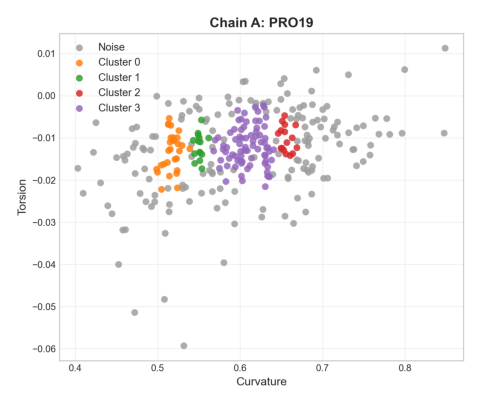

In [10]:
selected_residue = residue_clusters.summary_df.sort_values(
    ["n_clusters", "noise_fraction"], ascending=[False, True]
).iloc[0]
plot_path = result.outputs.cluster_plots_dir / f"A_{selected_residue['residue_label']}_clusters.png"
print(plot_path)
assert plot_path.is_file()
img = mpimg.imread(plot_path)
plt.figure(figsize=(6, 5))
plt.imshow(img)
plt.axis("off")
plt.show()

## Residue-range clustering

Residue-range clustering creates one feature vector per model by concatenating curvature and torsion values across the selected range. The `pc1` and `pc2` columns are a PCA projection for plotting the high-dimensional range signature.

In [11]:
range_clusters = result.residue_range_clustering
assert range_clusters is not None
range_clusters.summary_df

,chain,range_start,range_end,range_label,n_conformations,n_residues,n_clusters,noise_fraction
0,A,71,76,71-76,301,6,3,0.727575


In [12]:
range_clusters.assignments_df.head()

,chain,range_start,range_end,range_label,model,cluster,cluster_probability,pc1,pc2
0,A,71,76,71-76,0,-1,0.0,0.317801,1.085512
1,A,71,76,71-76,1,-1,0.0,-0.071446,-0.125695
10,A,71,76,71-76,10,-1,0.0,-0.235876,-0.125166
100,A,71,76,71-76,100,0,1.0,0.631854,-0.102478
101,A,71,76,71-76,101,0,1.0,0.746148,0.003429


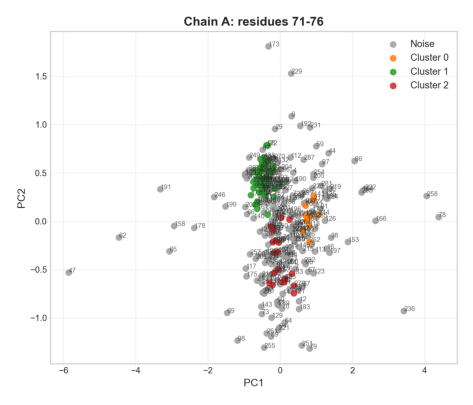

In [14]:
range_plot = result.outputs.range_cluster_plots_dir / "A_71-76_clusters.png"
assert range_plot.is_file()
img = mpimg.imread(range_plot)
plt.figure(figsize=(6, 5))
plt.imshow(img)
plt.axis("off")
plt.show()